<a href="https://www.kaggle.com/code/nicapotato/student-ai-tools-vs-exam-scores-eda?scriptVersionId=319845324" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Student AI Tools vs Exam Scores — EDA

Dataset: [muneebmuhammadali/student-ai-tools-vs-exam-scores](https://www.kaggle.com/datasets/muneebmuhammadali/student-ai-tools-vs-exam-scores) (CSV: `students_ai_usage.csv`).

Goal: compare self-reported grades before and after AI use, and relate **grades_after_ai** to study time, screen time, and how AI is used — for the usual “tools vs outcomes” framing on Kaggle.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import kagglehub
from IPython.display import display
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)

CSV_BASENAME = "students_ai_usage.csv"
KAGGLE_SLUG = "muneebmuhammadali/student-ai-tools-vs-exam-scores"

EXPECTED_COLS = [
    "age",
    "education_level",
    "study_hours_per_day",
    "uses_ai",
    "ai_tools_used",
    "purpose_of_ai",
    "grades_before_ai",
    "grades_after_ai",
    "daily_screen_time_hours",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            assert p.is_file()
            return p
        cands = [p for p in kaggle_root.rglob("*.csv") if p.is_file()]
        if cands:
            p = max(cands, key=lambda x: x.stat().st_size)
            assert p.is_file()
            return p
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / CSV_BASENAME
    assert p.exists(), f"expected {CSV_BASENAME} under {root}"
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
extra = set(df.columns) - set(EXPECTED_COLS)
assert not missing, f"missing columns: {sorted(missing)}"
assert not extra, f"unexpected columns: {sorted(extra)}"
assert df.shape == (100, len(EXPECTED_COLS))

df["grade_delta"] = df["grades_after_ai"] - df["grades_before_ai"]
assert df.shape[1] == len(EXPECTED_COLS) + 1

CAT_COLS = ["education_level", "uses_ai", "ai_tools_used", "purpose_of_ai"]
NUM_COLS = [
    "age",
    "study_hours_per_day",
    "grades_before_ai",
    "grades_after_ai",
    "grade_delta",
    "daily_screen_time_hours",
]

print(df.shape[0], "rows ×", df.shape[1], "cols")
display(df.sample(5, random_state=7))
display(df.dtypes)


CSV: /kaggle/input/datasets/muneebmuhammadali/student-ai-tools-vs-exam-scores/students_ai_usage.csv
100 rows × 10 cols


,age,education_level,study_hours_per_day,uses_ai,ai_tools_used,purpose_of_ai,grades_before_ai,grades_after_ai,daily_screen_time_hours,grade_delta
37,17,college,4.5,Yes,Copilot,Coding,75,81,2,6
26,14,school,4.7,No,NaN,NaN,62,62,2,0
78,18,college,3.6,No,NaN,NaN,69,69,5,0
91,16,school,1.9,No,NaN,NaN,65,65,6,0
49,19,college,3.9,Yes,Gemini,Research,59,74,7,15


age                          int64
education_level             object
study_hours_per_day        float64
uses_ai                     object
ai_tools_used               object
purpose_of_ai               object
grades_before_ai             int64
grades_after_ai              int64
daily_screen_time_hours      int64
grade_delta                  int64
dtype: object

## Univariate analysis

Frequency tables for categoricals (tool and purpose stay blank when **uses_ai** is No). **FacetGrid** histograms for all numeric fields, including **grade_delta** (after − before).



=== education_level ===


,count,pct
education_level,,
school,52,52.0
college,48,48.0



=== uses_ai ===


,count,pct
uses_ai,,
No,60,60.0
Yes,40,40.0



=== ai_tools_used ===


,count,pct
ai_tools_used,,
(missing),60,60.0
Copilot,14,14.0
Gemini,13,13.0
ChatGPT,13,13.0



=== purpose_of_ai ===


,count,pct
purpose_of_ai,,
(missing),60,60.0
Research,14,14.0
Homework,13,13.0
Coding,13,13.0


,count,mean,std,min,25%,50%,75%,max
age,100.0,16.490,1.702612,14.0,15.000,16.0,18.000,19.0
study_hours_per_day,100.0,2.987,1.145713,1.0,1.975,2.8,4.025,5.0
grades_before_ai,100.0,64.770,6.169090,55.0,59.000,63.0,70.000,75.0
grades_after_ai,100.0,68.700,8.140806,55.0,61.000,69.0,74.000,89.0
grade_delta,100.0,3.930,5.326236,0.0,0.000,0.0,8.000,15.0
daily_screen_time_hours,100.0,4.340,1.793479,2.0,3.000,4.0,6.000,7.0


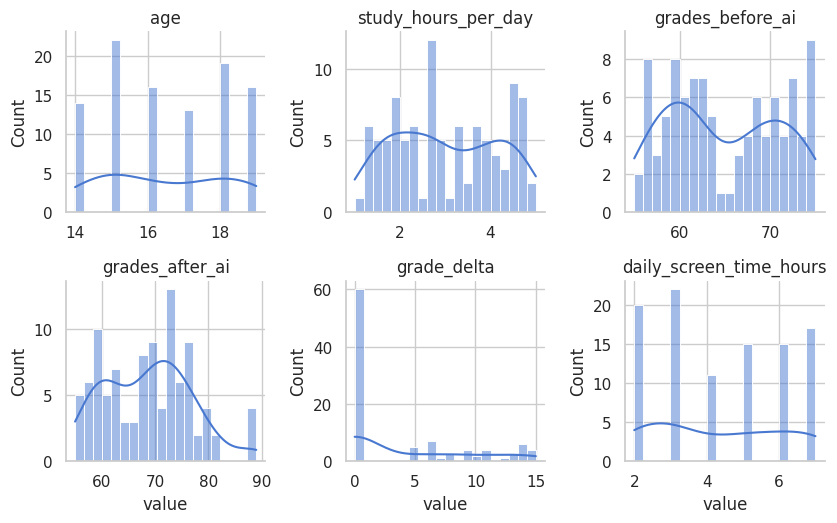

In [2]:
for col in CAT_COLS:
    s = df[col].fillna("(missing)")
    vc = s.value_counts()
    tab = pd.DataFrame({"count": vc, "pct": (vc / len(df) * 100).round(1)})
    print(f"\n=== {col} ===")
    display(tab)

display(df[NUM_COLS].describe().T)

long = df[NUM_COLS].melt(var_name="metric", value_name="value")
g = sns.FacetGrid(
    long,
    col="metric",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=2.7,
    aspect=1.05,
)
g.map_dataframe(sns.histplot, x="value", kde=True, bins=20)
g.set_titles(col_template="{col_name}")
g.tight_layout()
plt.show()


### Univariate reflection

- **Sample size (n = 100)** keeps every split coarse: small cell counts in cross-tabs and wide histogram bins. Treat subgroup patterns as exploratory, not definitive.
- **Grade delta** centers near zero for many rows but shows clear upward moves where AI is used for homework or research — useful as a quick “did scores move?” lens alongside **grades_after_ai**.


## Multivariate analysis

- **Two categorical:** row-% crosstab **uses_ai** × **education_level** with χ² test; heatmap for pattern.
- **Numeric × numeric:** Pearson correlation heatmap (including **grade_delta**).
- **Categorical × numeric:** boxplot of **grades_after_ai** by **uses_ai**, **hue** = **education_level**.
- **lmplot:** **study_hours_per_day** vs **grades_after_ai** with **uses_ai** as hue.


χ²(uses_ai × education_level) = 0.015, dof = 1, p = 0.902


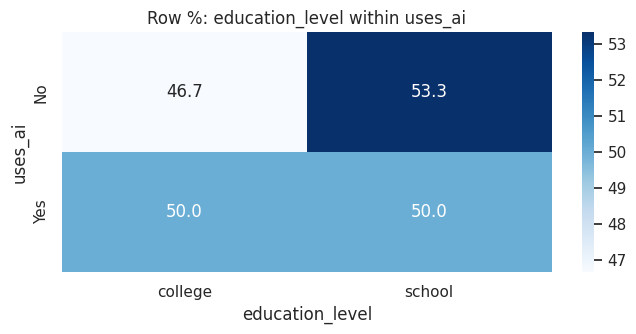

education_level,college,school
uses_ai,,
No,46.7,53.3
Yes,50.0,50.0


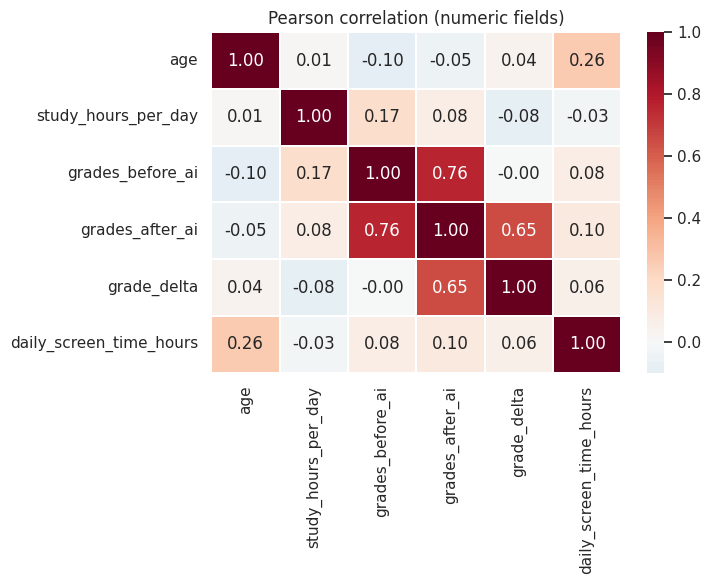

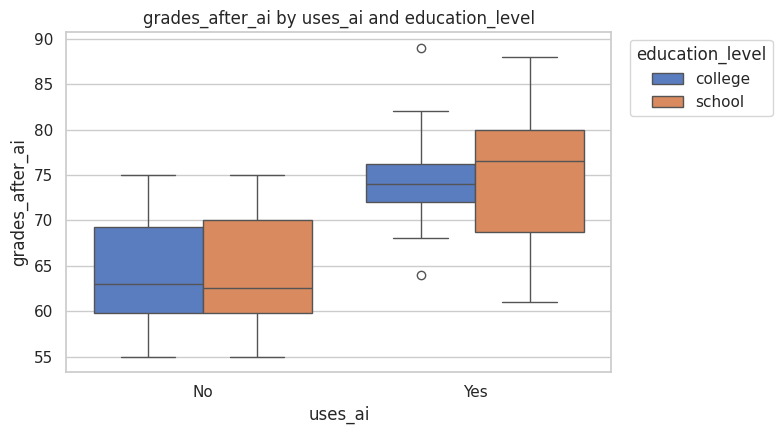

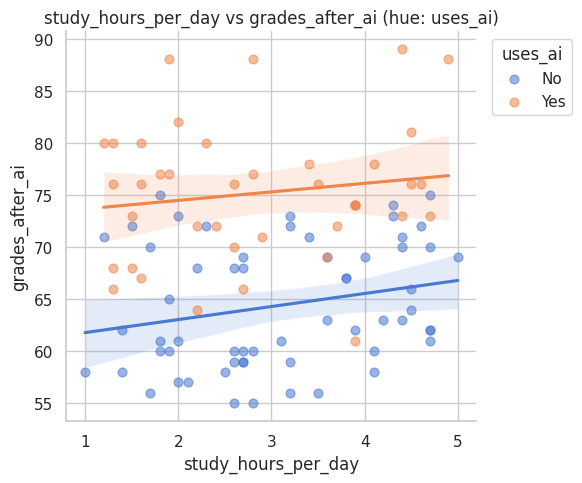

In [3]:
ct = pd.crosstab(df["uses_ai"], df["education_level"])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"χ²(uses_ai × education_level) = {chi2:.3f}, dof = {dof}, p = {p:.3g}")

xt = pd.crosstab(df["uses_ai"], df["education_level"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(xt, annot=True, fmt=".1f", cmap="Blues", ax=ax)
ax.set_title("Row %: education_level within uses_ai")
plt.tight_layout()
plt.show()

display(
    xt.style.background_gradient(cmap="Blues", axis=None).format("{:.1f}")
)

corr = df[NUM_COLS].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=0.2, ax=ax)
ax.set_title("Pearson correlation (numeric fields)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    data=df,
    x="uses_ai",
    y="grades_after_ai",
    hue="education_level",
    ax=ax,
)
ax.set_title("grades_after_ai by uses_ai and education_level")
ax.legend(title="education_level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

g = sns.lmplot(
    data=df,
    x="study_hours_per_day",
    y="grades_after_ai",
    hue="uses_ai",
    height=5,
    aspect=1.2,
    scatter_kws={"alpha": 0.55, "s": 40},
    legend=False,
)
g.ax.legend(title="uses_ai", bbox_to_anchor=(1.02, 1), loc="upper left")
g.ax.set_title("study_hours_per_day vs grades_after_ai (hue: uses_ai)")
plt.tight_layout()
plt.show()
